# HW5: Generative Adversarial Networks (GANs)

**Objective:** The goal of this assignment is to build, train, and evaluate a basic Generative Adversarial Network (GAN) capable of generating novel, realistic-looking handwritten digits.

***Note on Frameworks***

This notebook uses `Keras` with a `TensorFlow` backend. This assignment is more complex than previous ones, as it requires a custom training loop. Pay close attention to the instructions for training the Generator and Discriminator separately.

## Problem Statement

You are tasked with building a system that can **generate** new images of handwritten digits (0-9). You will not be classifying existing images; you will be creating *new* ones that look like they could have come from the original dataset.

**Dataset:**
We will use the **MNIST dataset**, which contains 60,000 training images of handwritten digits (28x28 pixels).

**Core GAN Concepts:**
A GAN consists of two competing neural networks:
1.  **The Generator (G):** The 'artist' or 'counterfeiter'. Its job is to take random noise (called *latent noise*) as input and try to create a fake image that looks real.
2.  **The Discriminator (D):** The 'art critic' or 'detective'. Its job is to look at an image (either real from the dataset or fake from the generator) and decide if it is **real (1)** or **fake (0)**.

**The Training "Minimax" Game:**
* The **Discriminator** is trained to get better at telling real and fake images apart.
* The **Generator** is trained to fool the Discriminator into thinking its fake images are real.

Over time, the Generator gets better at making realistic images, and the Discriminator gets better at spotting fakes. This "adversarial" competition pushes the Generator to produce highly realistic results.





In [3]:
# Import Libraries:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import random

from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, LeakyReLU, Dropout, Input
from keras.optimizers import Adam

# Set Seed: 
seed = 4337
np.random.seed(seed)
random.set_seed(seed)

## Part 1: Data Loading and Preprocessing

### 1a. Load the MNIST Dataset

We Loading the 60,000 training images from Keras using `mnist.load_data()`.
This gives us the "real" data that the Discriminator will learn from and the Generator will try to imitate. Note that for GANs, we don't need the labels (`y_train`, `y_test`), so we can ignore them (using `_` as a placeholder).

In [4]:
# 1. Load Data:
# We only need the training images (X_train). We don't need the labels (y_train)
# because GANs are an unsupervised learning method.
# YOUR CODE HERE: Load the MNIST dataset. Store the training images in 'X_train'.
# You can use '_' to ignore the other returned arrays (y_train, X_test, y_test).
(X_train, _), (_, _) = mnist.load_data() # YOUR CODE HERE...

print(f"Shape of training data: {X_train.shape}")

Shape of training data: (60000, 28, 28)


### 1b. Reshape and Scale the Data

We are converting the 28x28 pixel images into flat vectors and scaling their values from [0, 255] to [-1, 1].
Using `.reshape()` to flatten the images. Then, performing a mathematical operation `(image - 127.5) / 127.5`.
1.  **Reshaping:** Our initial GAN will use simple `Dense` layers, which expect flat vectors (784 features) as input, not 2D images (28x28).
2.  **Scaling to [-1, 1]:** This is a best practice for GANs. The Generator's output layer will use a `tanh` activation function, which outputs values in the [-1, 1] range. We *must* scale our real images to match this same range so the Discriminator can make a fair comparison.

In [5]:
# === 2. Reshape and Scale ===
# Our images are 28x28. We need to flatten them to 784-dimensional vectors.
image_size = X_train.shape[1] * X_train.shape[2] # 28 * 28 = 784

# YOUR CODE HERE: Reshape X_train. The new shape should be (60000, 784).
X_train = X_train.reshape(X_train.shape[0], image_size) # ... YOUR CODE ..

# Scale the data from [0, 255] to [-1, 1]
# This is the standard practice for GANs, as it pairs with the 'tanh' activation function.
# YOUR CODE HERE: Convert X_train to float32, then scale it.
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5 # ... YOUR CODE ...

print(f"Shape of data after reshaping: {X_train.shape}")
print(f"Data min value after scaling: {np.min(X_train)}")
print(f"Data max value after scaling: {np.max(X_train)}")

Shape of data after reshaping: (60000, 784)
Data min value after scaling: -1.0
Data max value after scaling: 1.0


### 1c. Define Constants

* `latent_dim`: The size of the random noise vector (e.g., 100) that will be fed into the Generator.
* `img_shape`: The shape of our flattened image (784).

In [6]:
# 3. Define Constants:
latent_dim = 100
img_shape = (image_size,)

print(f"Latent (noise) vector dimension: {latent_dim}")
print(f"Image vector shape: {img_shape}")

Latent (noise) vector dimension: 100
Image vector shape: (784,)


## Exercise 1: Build the GAN Components

We will now build the two separate models: the Generator and the Discriminator.

### 1a. Build the Generator (The "Artist")

We will build A neural network that takes a 100-dim noise vector and outputs a 784-dim vector (a fake image).
 Use a `Sequential` model. We'll use `Dense` layers with `LeakyReLU` activation (a common choice for GANs) to upsample the noise into a full image.
The final layer **must** use `tanh` activation. This forces the Generator's output to be in the [-1, 1] range, matching the scaled real images.

In [22]:
def build_generator():
    model = Sequential(name="Generator")

    # Input layer (takes 100-dim noise)
    # YOUR CODE HERE: Add a Dense layer with 256 units, LeakyReLU activation, and specify input_dim=latent_dim
    model.add(Dense(256, input_dim=latent_dim)) # ... YOUR CODE ...
    model.add(LeakyReLU(alpha=0.2))

    # Hidden layer
    # YOUR CODE HERE: Add a Dense layer with 512 units and LeakyReLU activation.
    model.add(Dense(512)) # ... YOUR CODE ...
    model.add(LeakyReLU(alpha=0.2))

    # Output layer
    # YOUR CODE HERE: Add a Dense layer with 'image_size' (784) units and 'tanh' activation.
    model.add(Dense(image_size, activation='tanh')) # ... YOUR CODE ...

    model.summary()
    return model

# Build the Generator
# YOUR CODE HERE: Call the build_generator() function and store the model in 'generator'.
generator = build_generator() # ... YOUR CODE ...

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,632 (2.13 MB)

 Trainable params: 559,632 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

### 1b. Build the Discriminator (The "Critic")

We will build a neural network that takes a 784-dim vector (an image) and outputs a single probability (0 = fake, 1 = real).
Use a `Sequential` model. This is a standard binary classifier. We use `Dense` layers with `LeakyReLU` and `Dropout` (to prevent overfitting).
The final layer **must** use `sigmoid` activation. This squashes the output to a probability between 0 and 1.

In [17]:
def build_discriminator():
    model = Sequential(name="Discriminator")

    # Input layer (takes 784-dim image vector)
    # YOUR CODE HERE: Add a Dense layer with 512 units, LeakyReLU activation, and specify input_shape=img_shape
    model.add(Dense(512, input_shape=img_shape)) # ... YOUR CODE ...
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    # Hidden layer
    # YOUR CODE HERE: Add a Dense layer with 256 units and LeakyReLU activation.
    model.add(Dense(256)) # ... YOUR CODE ...
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    # Output layer
    # YOUR CODE HERE: Add a Dense layer with 1 unit and 'sigmoid' activation.
    model.add(Dense(1, activation='sigmoid')) # ... YOUR CODE ...

    model.summary()
    return model

# Build and compile the Discriminator
# YOUR CODE HERE: Call the build_discriminator() function and store the model in 'discriminator'.
discriminator = build_discriminator() # ... YOUR CODE ...

# YOUR CODE HERE: Compile the discriminator.
# Use 'Adam' optimizer, 'binary_crossentropy' loss, and 'accuracy' as a metric.
discriminator.compile( # ... YOUR CODE ...
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
    
print("Discriminator compiled.")

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Discriminator compiled.


## Exercise 2: Build the Combined GAN Model

We are creating a third, "combined" model where the Generator's output is fed directly into the Discriminator (`G(noise) -> D`).
Use the Keras functional API (`Model`) to chain `generator` and `discriminator` together.
This combined model is used *only* to train the Generator. When we train this model, we will **freeze the Discriminator's weights**. This way, all the error signals flow back and *only* update the Generator's weights, teaching it how to change its output to better fool the (currently frozen) Discriminator.

In [18]:
# === Build the Combined GAN Model ===

# Define the input for the combined model (this is the noise for the Generator)
# YOUR CODE HERE: Create an Input layer with shape (latent_dim,)
z = Input(shape=(latent_dim,)) # ... YOUR CODE ...

# Pass the noise through the Generator to create an image
# YOUR CODE HERE: Pass 'z' (the input) into the 'generator' model.
img = generator(z) # ... YOUR CODE ...

# --- FREEZE DISCRIMINATOR WEIGHTS ---
# This is the most important step for training the generator.
# We set the discriminator's weights to be non-trainable.
# Why? When training the combined GAN, we only want to update the *generator's* weights.
# We want to "fool" the discriminator, not make the discriminator better at classifying.
# YOUR CODE HERE: Set the 'trainable' property of the 'discriminator' model to False.
discriminator.trainable = False # ... YOUR CODE ...

# Pass the generated image (img) through the (frozen) Discriminator
# YOUR CODE HERE: Pass 'img' (from the generator) into the 'discriminator' model.
validity = discriminator(img) # ... YOUR CODE ...

# Create the combined model
# Input is 'z' (noise), Output is 'validity' (0 or 1)
# YOUR CODE HERE: Create the combined 'Model' (from keras.models).
# It takes 'z' as its input and 'validity' as its output.
gan = Model(inputs=z, outputs=validity, name="GAN_Model") # ... YOUR CODE ...

# --- Compile the Combined GAN ---
# This compilation only affects the Generator (since D is frozen).
# YOUR CODE HERE: Compile the 'gan' model.
# Use 'Adam' optimizer and 'binary_crossentropy' loss.
gan.compile(
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy'
)

print("\n--- Combined GAN Model Summary --- ")
gan.summary()
print(f"\nIs Discriminator trainable in GAN model? {discriminator.trainable}")


--- Combined GAN Model Summary --- 


Model: "GAN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 784)            │     1,486,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,019,857 (7.71 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 533,505 (2.04 MB)


Is Discriminator trainable in GAN model? False


## Exercise 3: Create the Custom Training Loop

We are writing the code that alternates between training the Discriminator and the Generator.
We'll write a `for` loop that runs for a set number of epochs. Inside this loop, we will:
1.  **Train Discriminator:** a. Get a batch of real images from `X_train`. Label them as `1` (real).
    b. Generate a batch of fake images using `generator.predict()`. Label them as `0` (fake).
    c. Train the discriminator on both batches using `discriminator.train_on_batch()`.
2.  **Train Generator:**
    a. Generate a batch of random noise.
    b. Create a set of "misleading" labels, all `1`s (real).
    c. Train the *combined `gan` model* using `gan.train_on_batch()`, passing in the noise and the misleading labels. This updates *only* the generator's weights.

 A simple `.fit()` won't work. We need this custom loop to manage the "minimax" game, ensuring one model doesn't overpower the other too quickly.

### 3a. Helper Function to Plot Images

A function to save a grid of our generated images.
We will call this function every few epochs to visually check our Generator's progress.

In [19]:
# This function is provided for you. No code needed here.
def plot_generated_images(epoch, generator, examples=16, dim=(4, 4), figsize=(7, 7)):
    noise = np.random.normal(0, 1, size=[examples, latent_dim])
    generated_images = generator.predict(noise, verbose=0) # Set verbose=0 to avoid spam
    generated_images = generated_images.reshape(examples, 28, 28)

    plt.figure(figsize=figsize)
    for i in range(generated_images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(generated_images[i], interpolation='nearest', cmap='gray_r')
        plt.axis('off')
    plt.tight_layout()
    plt.suptitle(f'Generated Images at Epoch {epoch}', y=1.03)
    plt.show()

### 3b. The Training Loop

**Instructions:** Fill in the `YOUR CODE HERE` sections inside the loop. This is the most important part of the assignment.

**Note:** Results will not look as good on 50 epochs but we are doing this to learn so it does not matter as much ! Adjust epochs according to your system

Starting Training...
0 [D loss: 0.9360, acc.: 45.51%] [G loss: 0.8005]


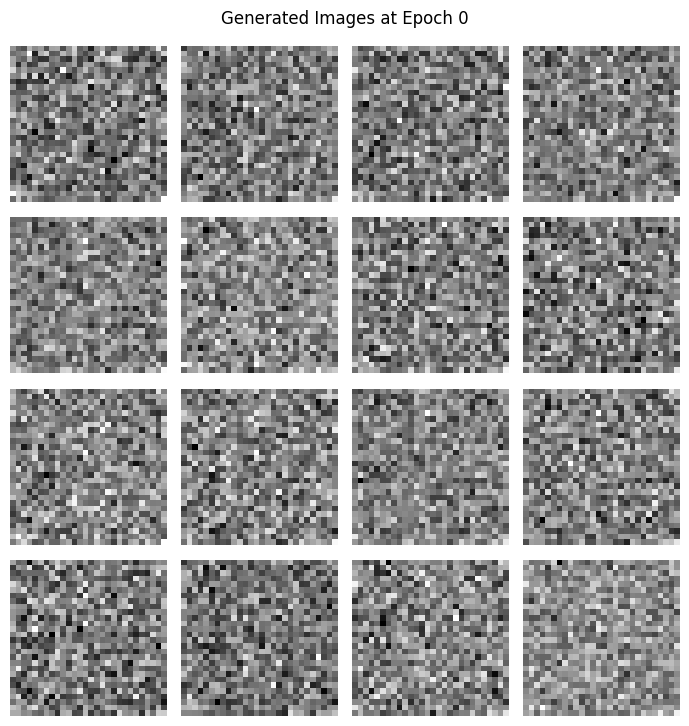

100 [D loss: 4.6208, acc.: 20.57%] [G loss: 0.0275]


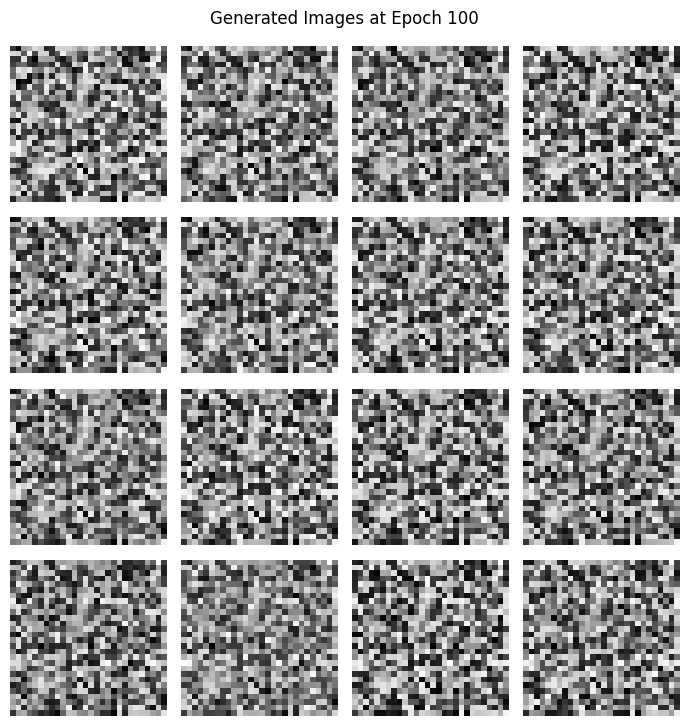

200 [D loss: 5.3972, acc.: 20.45%] [G loss: 0.0139]


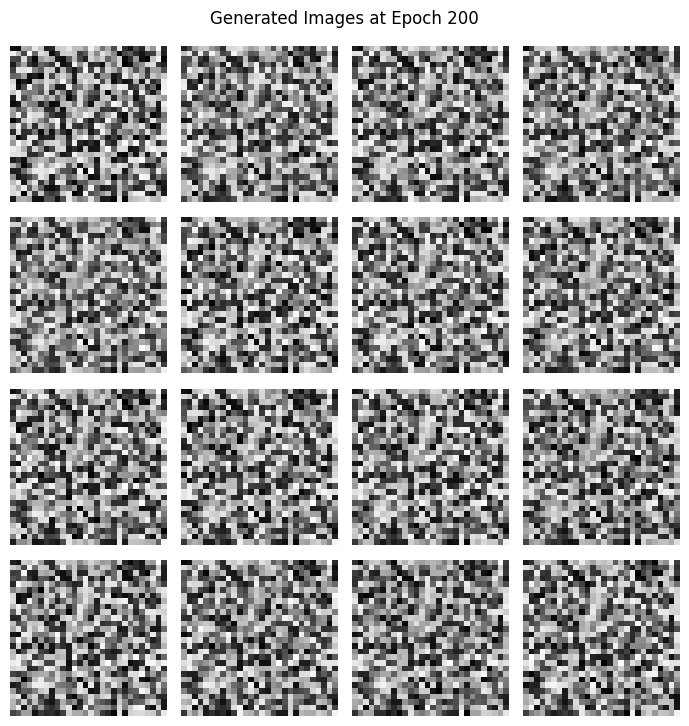

300 [D loss: 5.8279, acc.: 20.35%] [G loss: 0.0093]


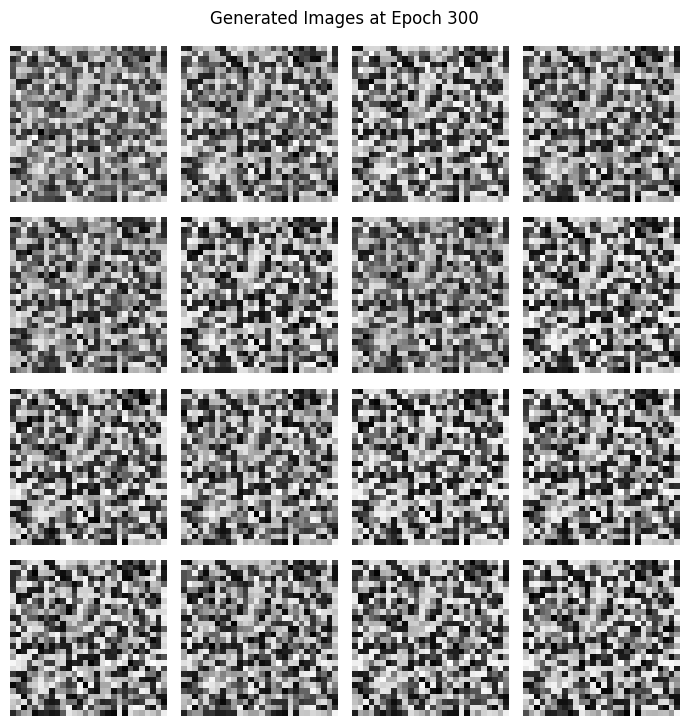

400 [D loss: 6.1211, acc.: 20.23%] [G loss: 0.0070]


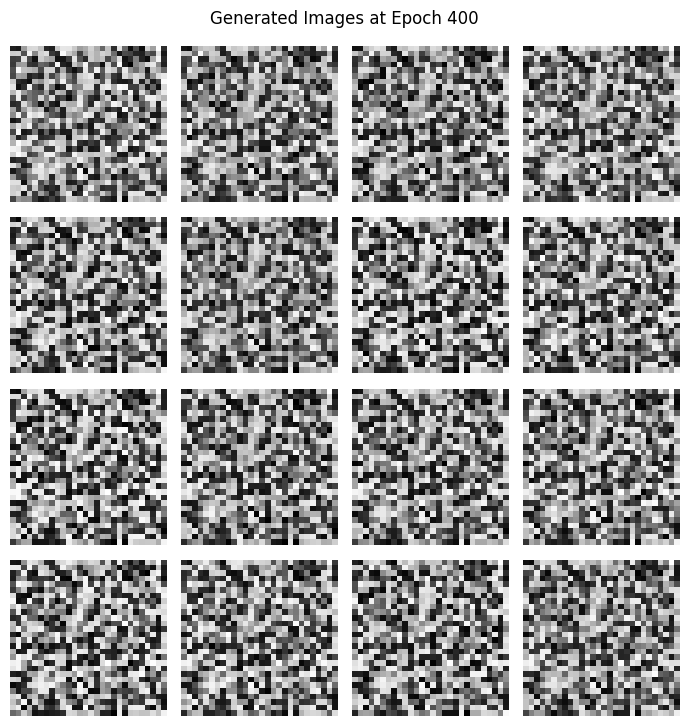

500 [D loss: 6.3438, acc.: 20.26%] [G loss: 0.0056]


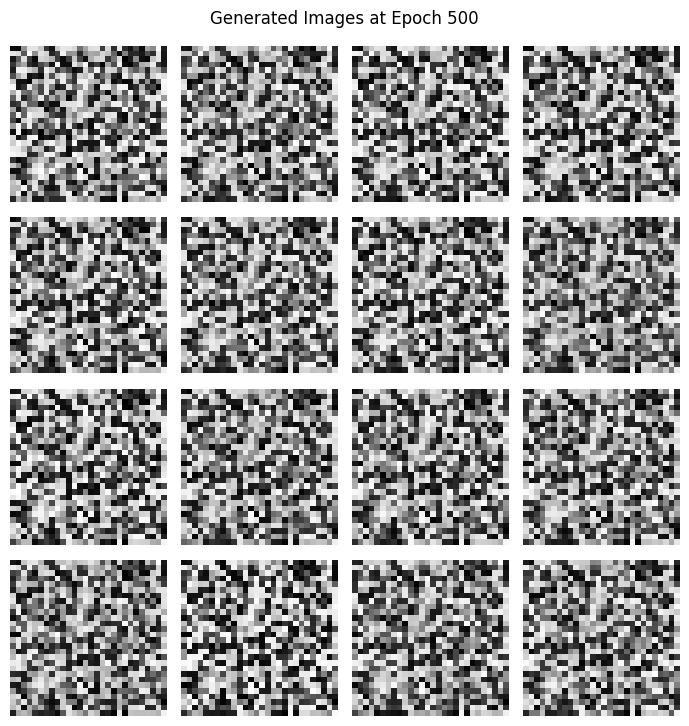

600 [D loss: 6.5182, acc.: 20.24%] [G loss: 0.0047]


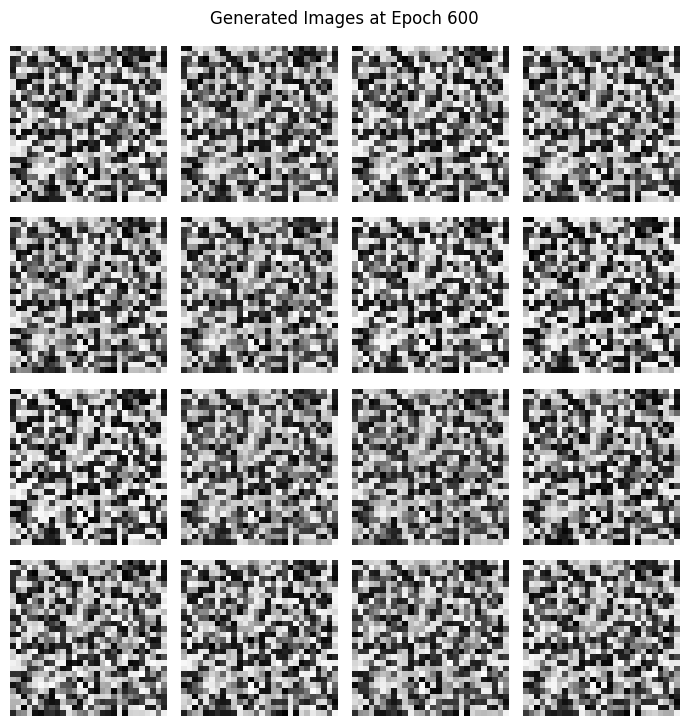

700 [D loss: 6.6674, acc.: 20.23%] [G loss: 0.0040]


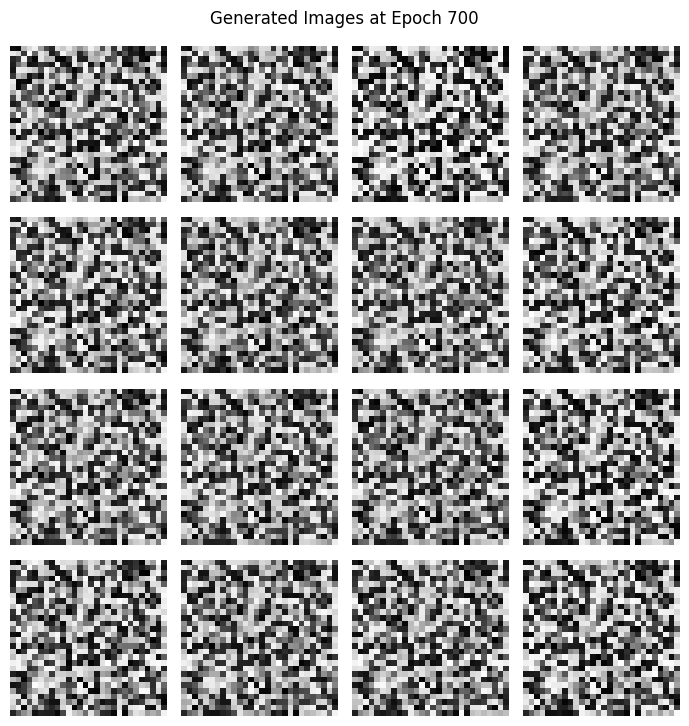

800 [D loss: 6.7964, acc.: 20.20%] [G loss: 0.0035]


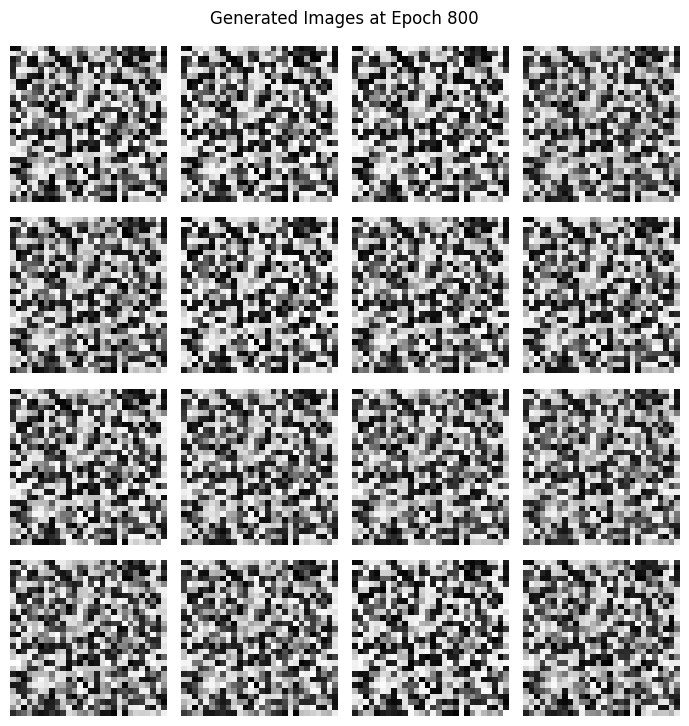

900 [D loss: 6.9056, acc.: 20.19%] [G loss: 0.0031]


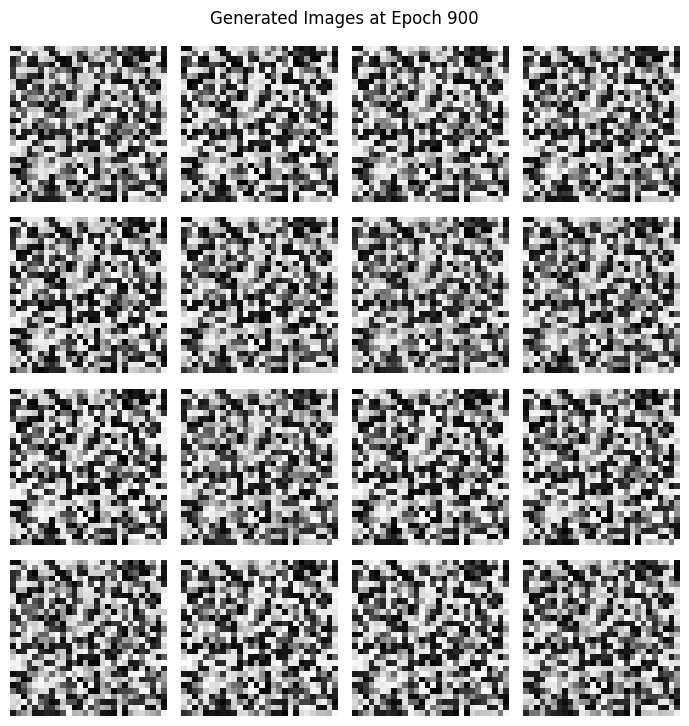

1000 [D loss: 7.0022, acc.: 20.15%] [G loss: 0.0028]


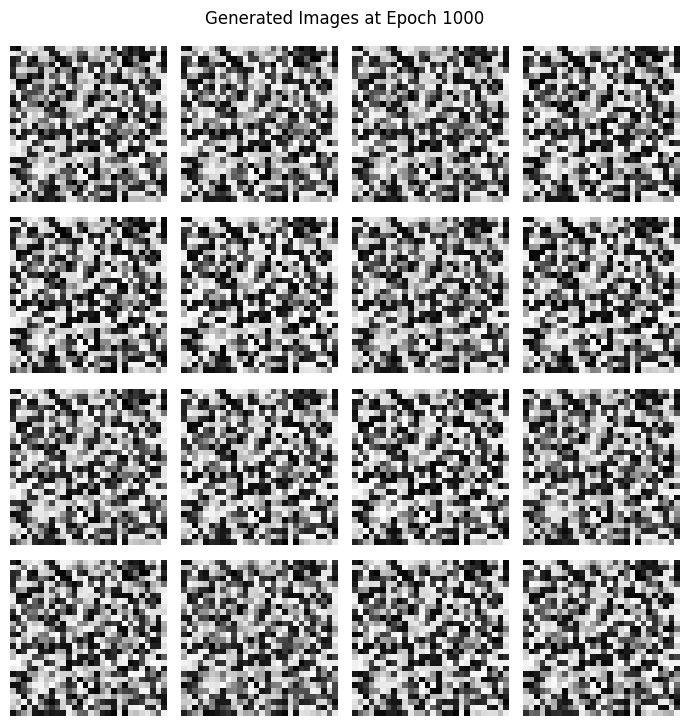

Training Complete! 🎉


In [20]:
# Define Training Parameters:
epochs = 1000 # Change epoch accordingly
batch_size = 128
sample_interval = 100 # How often to save and plot generated images

# Initialize Arrays to Store Losses:
d_losses = []
g_losses = []

# Create Ground Truth Labels:
# Create arrays of 1s (real) and 0s (fake) for training the discriminator
# YOUR CODE HERE: Create 'real_labels', an array of ones. Shape: (batch_size, 1).
real_labels = np.ones((batch_size, 1))

# YOUR CODE HERE: Create 'fake_labels', an array of zeros. Shape: (batch_size, 1).
fake_labels = np.zeros((batch_size, 1))

# --- Start Training Loop ---
print("Starting Training...")
for epoch in range(epochs + 1):
    #  Train Discriminator
    # 1. Get a random batch of real images
    # YOUR CODE HERE: Select a random batch of 'batch_size' images from 'X_train'.
    # Use np.random.randint() to get random indices.
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_images = X_train[idx]

    # 2. Generate a batch of fake images
    # YOUR CODE HERE: Create 'noise' - a numpy array of random normal noise.
    # Shape should be (batch_size, latent_dim).
    noise = np.random.normal(-1, 1, (batch_size, latent_dim))

    # YOUR CODE HERE: Generate fake images by passing 'noise' to the 'generator.predict()'.
    fake_images = generator.predict(noise, verbose=0)

    # 3. Train the discriminator on real images
    # YOUR CODE HERE: Train the 'discriminator' on 'real_images' and 'real_labels'.
    # Use discriminator.train_on_batch(). Store the output (loss, acc) in 'd_loss_real'.
    d_loss_real = discriminator.train_on_batch(real_images, real_labels)

    # 4. Train the discriminator on fake images
    # YOUR CODE HERE: Train the 'discriminator' on 'fake_images' and 'fake_labels'.
    # Store the output in 'd_loss_fake'.
    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

    # 5. Calculate average discriminator loss
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    #  Train Generator

    # 6. Generate a new batch of noise
    # YOUR CODE HERE: Create 'noise' again. Shape: (batch_size, latent_dim).
    noise = np.random.normal(0, 1, (batch_size, latent_dim))

    # 7. Train the generator (via the combined GAN model)
    # We want the generator to make images that the discriminator thinks are *real* (label 1).
    # YOUR CODE HERE: Train the combined 'gan' model on 'noise' and 'real_labels'.
    # Store the output loss in 'g_loss'.
    g_loss = gan.train_on_batch(noise, real_labels)

    # --- Log Progress and Plot Images ---
    if (epoch % sample_interval == 0):
        print(f"{epoch} [D loss: {d_loss[0]:.4f}, acc.: {d_loss[1]*100:.2f}%] [G loss: {g_loss:.4f}]")

        # Store losses
        d_losses.append(d_loss[0])
        g_losses.append(g_loss)

        # Plot generated images
        plot_generated_images(epoch, generator)

print("Training Complete! 🎉")

## Exercise 4: Final Evaluation

### 4a. Plot Generator and Discriminator Losses

Plot the `g_loss` and `d_loss` that we saved during training.
Use matplotlib to plot the `d_losses` and `g_losses` lists on the same graph.
This helps visualize the "minimax" game. In an ideal (but rare) scenario, the losses would converge to a stable equilibrium. More commonly, you'll see them oscillate as one model gets temporarily better than the other.

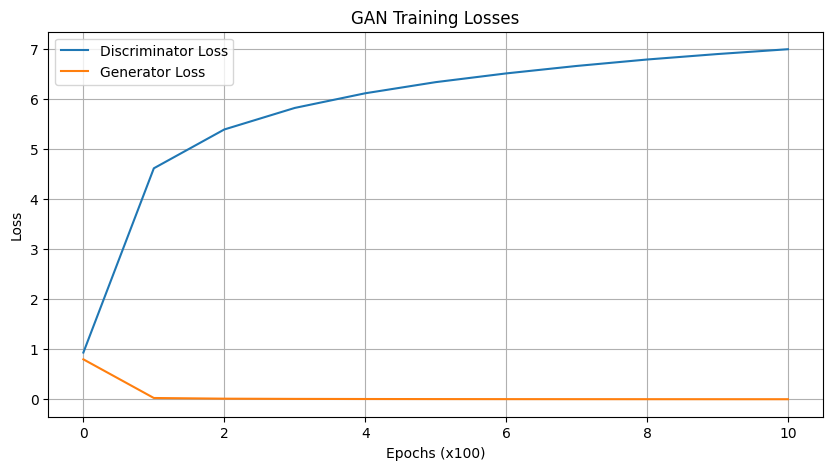

In [21]:
# === Plot Final Losses ===
plt.figure(figsize=(10, 5))
# YOUR CODE HERE: Plot the 'd_losses' list. Label it 'Discriminator Loss'.
plt.plot(d_losses, label="Discriminator Loss")

# YOUR CODE HERE: Plot the 'g_losses' list. Label it 'Generator Loss'.
plt.plot(g_losses, label="Generator Loss")

plt.title("GAN Training Losses")
# X-axis label is based on our sample_interval
plt.xlabel(f"Epochs (x{sample_interval})")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Exercise 5: Analysis and Questions

**Instructions:** Answer the following questions based on the models you built and the results you obtained.

**1. Component Roles:** In your own words, what is the job of the **Generator**? What is the job of the **Discriminator**?

Generator: the Generator's job is to create fake images that look like handwritten digits. It takes random noise and tries to turn it into something realistic

Discriminator: the Discriminator's job is to look at an image and decide if it is real (from the dataset) or fake (from the Generator)

**2. Scaling and Activation:** * Why did we scale the *real* images (X_train) to the range [-1, 1]?
    * Which activation function did we use on the **Generator's** final layer, and why was this specific function chosen?

We scaled the real to [-1, 1] because the Generator uses the tanh activation function, which also output values in the range [-1, 1]. This helps make training more stable and consistent

We chose tanh because: it outputs values between -1 and 1, it matches out scaled image data, it helps the Generator learn smoother image distributions

**3. Training the Combined Model (The "Tricky" Part):**
    * When we trained the combined `gan` model (in Step 7 of the loop), which model's weights were actually being updated (Generator or Discriminator)?
    * Why did we have to **freeze** the weights of the other model before compiling the `gan` model?

When we trained the combined 'gan' model, only the Generator's weights were updated. Before building the gan model, we set:

`discriminator.trainable = False`

So when we compiled and trained gan, Keras only computed gradients and updated parameters for the Generator. We had to freeze the Discriminator because we want the Generator to learn how to produce images that the already-trained Discriminator classifies as "real". If we didn't freeze the Discriminator, both networks would move at the same time

**4. Misleading Labels:** When training the **Generator** (in Step 7 of the loop), we passed in a batch of `noise` and a batch of `real_labels` (all 1s). Why did we use labels for "real" images here? What were we trying to "trick"?

During Generator training, we call:

`g_loss = gan.train_on_batch(noise, real_labels)`

Here, real_labels is a vector of ones (label "real"), even though the images come from the Generator, not the dataset. We do this on purpose to trick the Discriminator: we're asking the Generator to produce fake images that the Discriminator will classify as 1 (real).

In other words, we are optimizing the Generator so that the Discriminator's output on G(z) gets as close to 1 as possible. The labels are "misleading" because they tell the Discriminator target "real", but the input is actually fake. That's how the Generator learns to fool the Discriminator.

**5. Loss Curve Analysis:** Look at your final "GAN Training Losses" plot.
* Did the losses converge to a stable point, or did they oscillate (go up and down)?
* What does it mean if the **Discriminator Loss (d_loss)** drops to near zero and stays there? Is this a good or bad outcome for training?
* What does it mean if the **Generator Loss (g_loss)** drops to near zero? Is this good or bad?

The losses didn't go perfectly flat, they kind of went up and down, which is normal for GANs
* If the Discriminator loss stays near zero, it means it's too good and the Generator isn't learning much
* If the Geneartor loss is near zero, it means it's doing a good job tricking the Discriminator

**6. Image Quality Analysis:** Look at the grid of images your generator produced.
    * Describe the progression. What did the images look like at the beginning versus the end?
    * Were the final images perfect? Did they look like recognizable digits, or were they still blurry/nonsensical? (This is known as "mode collapse" if it only produces one or two digits, or just noise).

At the beginning, the images looked like random blurry noises. As training went on, the images dont look recognizable, and even further modificaitons like going to 1000 epochs didn't help.

## 5. Deliverables

Please submit:
1.  This completed Jupyter Notebook file (`.ipynb`) with all code cells executed and outputs (including loss plots and generated image grids) clearly visible. (25% penalty for not doing so)
2.  An exported HTML version of this notebook (`File -> Download as -> HTML`). **(Important: 25% penalty if HTML is not submitted)**